In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

In [2]:
df = pd.read_csv("../data/raw/train.csv",parse_dates=["date"])

In [3]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
df.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


In [6]:
df.shape

(913000, 4)

In [7]:
df.date.min(),df.date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-12-31 00:00:00'))

In [8]:
df.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [9]:
df.groupby(["store","item"])["date"].count()

store  item
1      1       1826
       2       1826
       3       1826
       4       1826
       5       1826
               ... 
10     46      1826
       47      1826
       48      1826
       49      1826
       50      1826
Name: date, Length: 500, dtype: int64

<Axes: xlabel='store'>

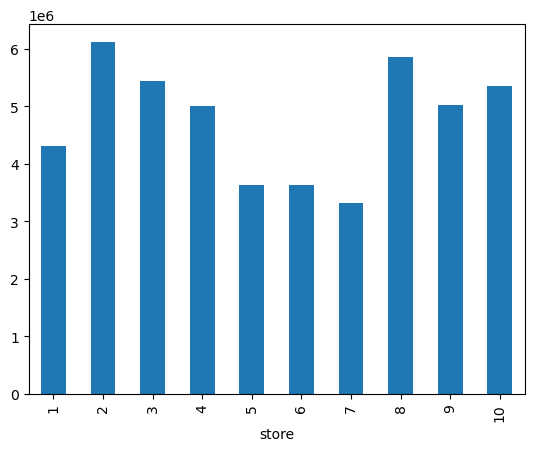

In [10]:
store_sales = df.groupby("store")['sales'].sum()
store_sales.plot(kind="bar")

<Axes: xlabel='item'>

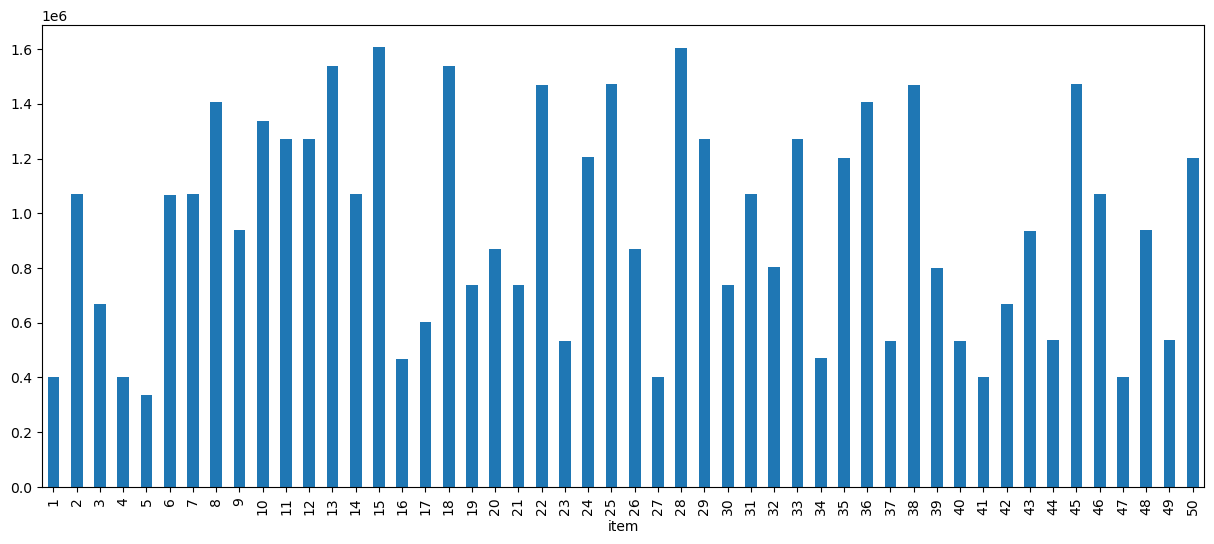

In [11]:
item_sales = df.groupby("item")['sales'].sum()
plt.figure(figsize=(15,6))
item_sales.plot(kind='bar')

<Axes: xlabel='date', ylabel='sales'>

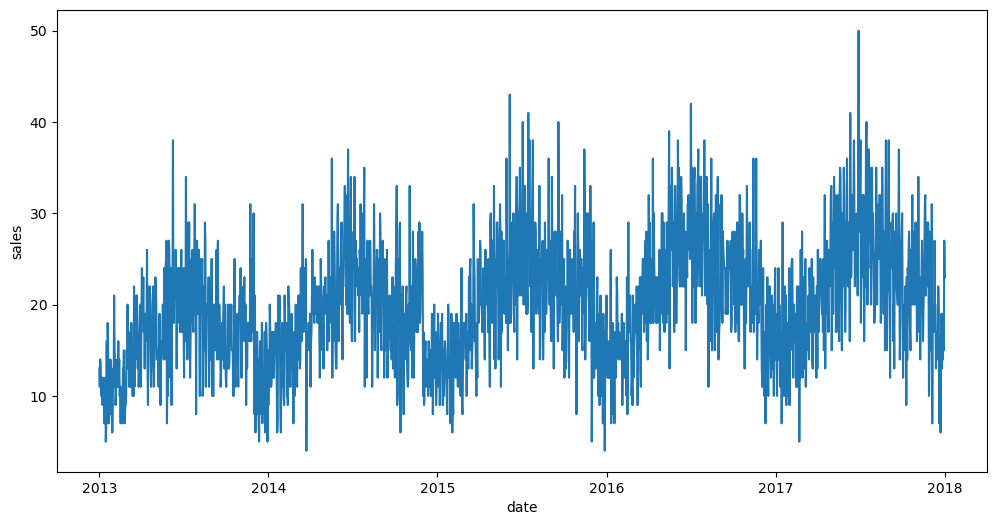

In [12]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df[(df['store']==1) & (df['item']==1)],x="date",y="sales")

In [13]:
store_item_combinations = df[['store','item']].drop_duplicates()

In [ ]:
for store,item in store_item_combinations.values:
    store_item_data = df[(df['store']==store) & (df['item']==item)]
    plt.figure(figsize=(15,6))
    sns.lineplot(data=store_item_data,x='date',y='sales')
    plt.title(f"Sales trend for store {store} and item {item}")

<Axes: xlabel='month'>

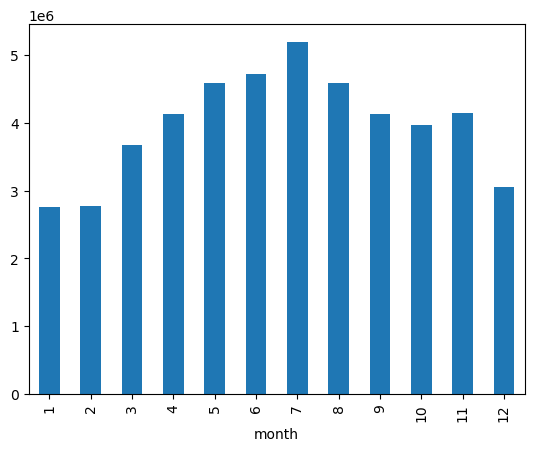

In [14]:
df['month'] = df['date'].dt.month

monthly_sales = df.groupby('month')['sales'].sum()
monthly_sales.plot(kind='bar')

<Axes: xlabel='day_of_week'>

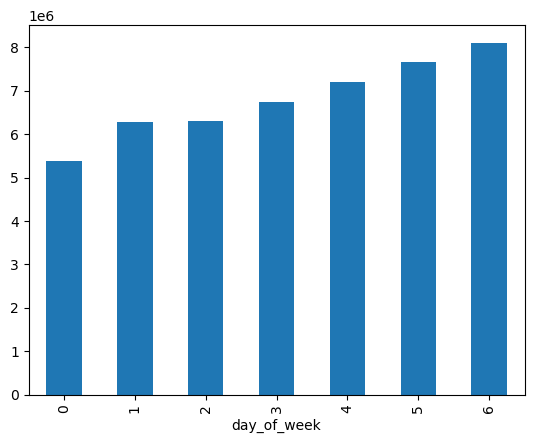

In [15]:
df['day_of_week'] = df['date'].dt.dayofweek
day_wise_sales = df.groupby('day_of_week')['sales'].sum()
day_wise_sales.plot(kind='bar')

<Axes: xlabel='year'>

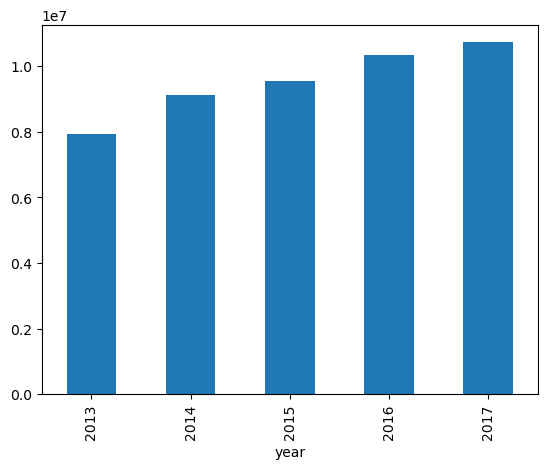

In [16]:
df['year'] = df['date'].dt.year
yearly_sales = df.groupby('year')['sales'].sum()
yearly_sales.plot(kind='bar')

In [ ]:
for store,item in store_item_combinations.values:
    store_item_data = df[(df['store']==store) & (df['item']==item)][['date','sales']]
    store_item_data.set_index('date',inplace=True)
    plot_pacf(store_item_data)
    plt.title(f"PACF for store {store} and item {item}")
    plot_acf(store_item_data)
    plt.title(f"ACF for store {store} and item {item}")
    
    

<Axes: >

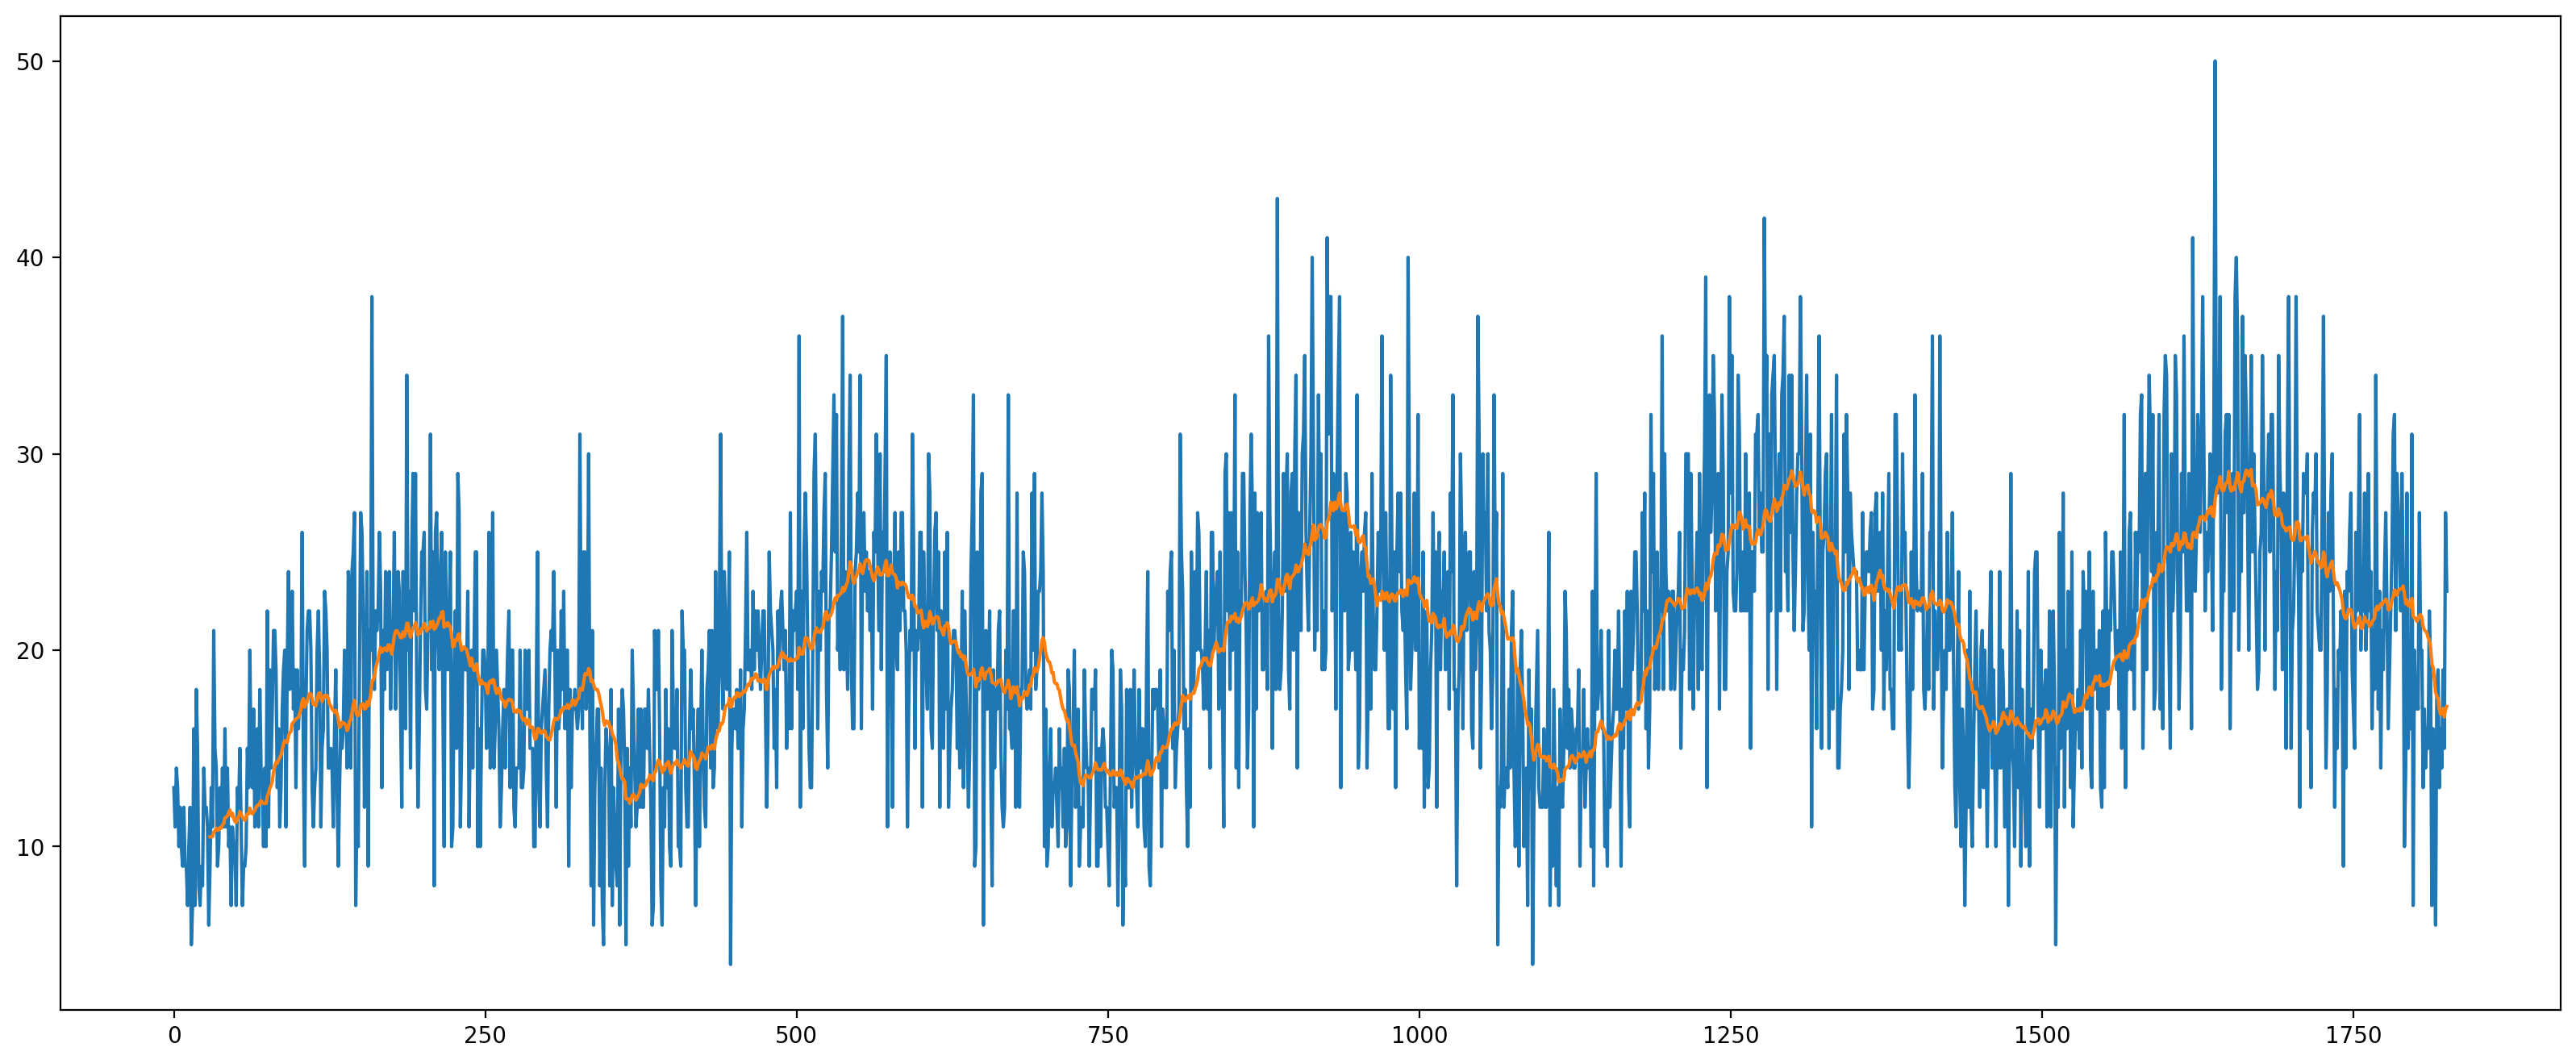

In [17]:
sales_subset = df[(df['store']==1) & (df['item']==1)]
plt.figure(figsize=(20,8),dpi=200)
sales_subset['sales'].plot()
sales_subset['sales'].rolling(30).mean().plot()


In [18]:
df['date'].min() , df['date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-12-31 00:00:00'))